## Steane 7-Qubit Code 2

Steane 7-Qubit Error Correction (Ultra-Fast Version)

1. Circuit Visualisation (Compact Layout)

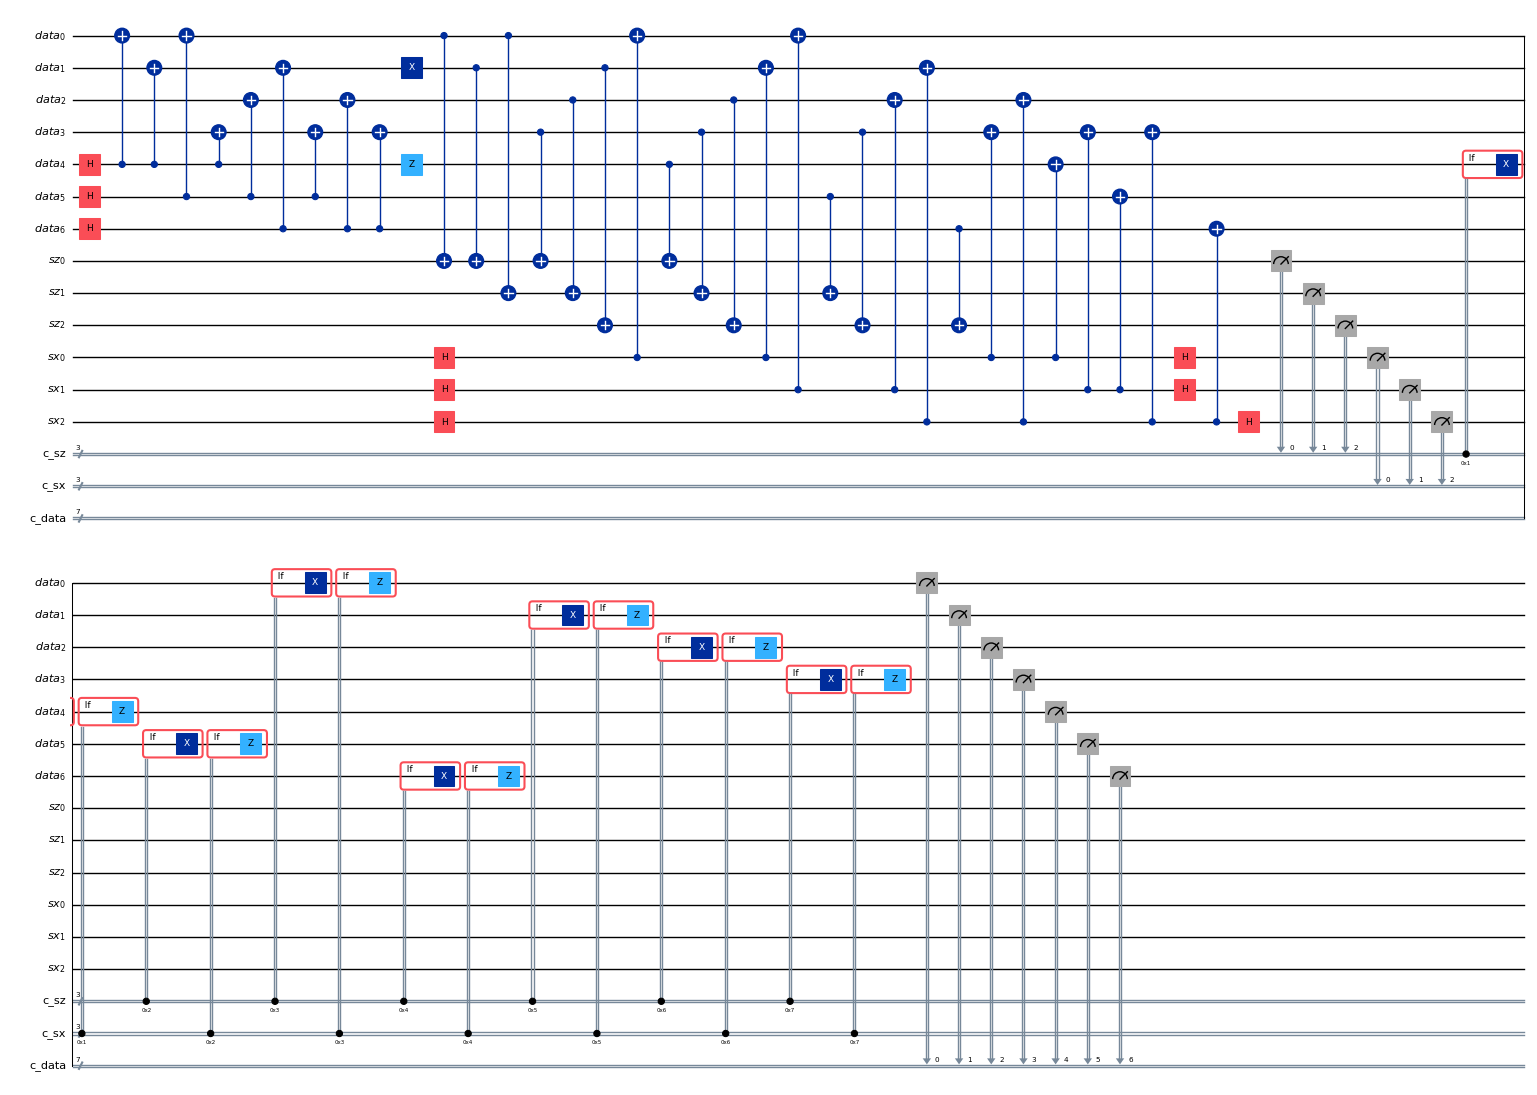

2. Measurement Analysis

Because calculating a 13-qubit density matrix freezes the kernel, we verify success by checking if the final measurements form valid Hamming [7,4,3] codewords.


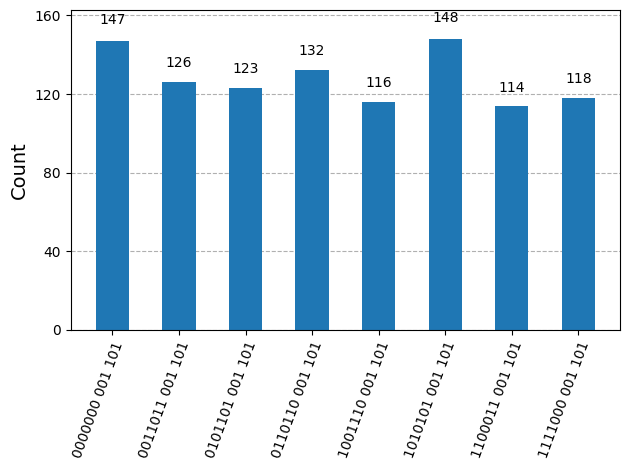

3. Verification

Success: 100% of measurements collapsed into valid |0_L> Hamming codewords despite the errors.


In [61]:
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display, Markdown

# ==========================================
# CONFIGURATION
# ==========================================
error_x_qubit = 1  # Bit-flip (X) on Qubit 1
error_z_qubit = 4  # Phase-flip (Z) on Qubit 4

# 1. Set up Registers & Circuit (13 Qubits)
qr_data = QuantumRegister(7, name="data")
qr_sz = QuantumRegister(3, name="sz")     # Z-syndromes
qr_sx = QuantumRegister(3, name="sx")     # X-syndromes
cr_sz = ClassicalRegister(3, name="c_sz")
cr_sx = ClassicalRegister(3, name="c_sx")
cr_data = ClassicalRegister(7, name="c_data")

qc = QuantumCircuit(qr_data, qr_sz, qr_sx, cr_sz, cr_sx, cr_data)

# 2. Encode Logical |0_L> 
qc.h([qr_data[4], qr_data[5], qr_data[6]])
qc.cx(qr_data[4], qr_data[0]); qc.cx(qr_data[4], qr_data[1]); qc.cx(qr_data[4], qr_data[3])
qc.cx(qr_data[5], qr_data[0]); qc.cx(qr_data[5], qr_data[2]); qc.cx(qr_data[5], qr_data[3])
qc.cx(qr_data[6], qr_data[1]); qc.cx(qr_data[6], qr_data[2]); qc.cx(qr_data[6], qr_data[3])
qc.barrier(label="|0_L> Encoded")

# 3. Inject Errors
if error_x_qubit is not None: qc.x(qr_data[error_x_qubit])
if error_z_qubit is not None: qc.z(qr_data[error_z_qubit])
qc.barrier(label="Errors Injected")

# 4. Syndrome Extraction
# Z-Checks for X-Errors
qc.cx(qr_data[0], qr_sz[0]); qc.cx(qr_data[1], qr_sz[0]); qc.cx(qr_data[3], qr_sz[0]); qc.cx(qr_data[4], qr_sz[0])
qc.cx(qr_data[0], qr_sz[1]); qc.cx(qr_data[2], qr_sz[1]); qc.cx(qr_data[3], qr_sz[1]); qc.cx(qr_data[5], qr_sz[1])
qc.cx(qr_data[1], qr_sz[2]); qc.cx(qr_data[2], qr_sz[2]); qc.cx(qr_data[3], qr_sz[2]); qc.cx(qr_data[6], qr_sz[2])

# X-Checks for Z-Errors
qc.h(qr_sx)
qc.cx(qr_sx[0], qr_data[0]); qc.cx(qr_sx[0], qr_data[1]); qc.cx(qr_sx[0], qr_data[3]); qc.cx(qr_sx[0], qr_data[4])
qc.cx(qr_sx[1], qr_data[0]); qc.cx(qr_sx[1], qr_data[2]); qc.cx(qr_sx[1], qr_data[3]); qc.cx(qr_sx[1], qr_data[5])
qc.cx(qr_sx[2], qr_data[1]); qc.cx(qr_sx[2], qr_data[2]); qc.cx(qr_sx[2], qr_data[3]); qc.cx(qr_sx[2], qr_data[6])
qc.h(qr_sx)
qc.barrier(label="Syndromes Extracted")

# Measure Syndromes
qc.measure(qr_sz, cr_sz)
qc.measure(qr_sx, cr_sx)

# 5. Dynamic Correction
syndrome_map = {1: 4, 2: 5, 3: 0, 4: 6, 5: 1, 6: 2, 7: 3}
for decimal_val, qubit_idx in syndrome_map.items():
    with qc.if_test((cr_sz, decimal_val)): qc.x(qr_data[qubit_idx])
    with qc.if_test((cr_sx, decimal_val)): qc.z(qr_data[qubit_idx])
qc.barrier(label="Corrected")

# 6. Fast Measurement (No Density Matrix)
qc.measure(qr_data, cr_data)

simulator = AerSimulator()
tqc = transpile(qc, simulator)
job = simulator.run(tqc, shots=1024)
counts = job.result().get_counts()

# ==========================================
# REQUIRED COURSEWORK OUTPUTS
# ==========================================

display(Markdown(f"Steane 7-Qubit Error Correction (Ultra-Fast Version)"))
display(Markdown("1. Circuit Visualisation (Compact Layout)"))
# scale=0.5 shrinks the image by 50%
# fold=45 wraps the circuit to a new line much earlier to prevent horizontal scrolling
# plot_barriers=False hides the grey vertical lines to tighten the gate spacing
display(qc.draw('mpl', scale=0.5, fold=45, plot_barriers=False))

display(Markdown("2. Measurement Analysis"))
print("Because calculating a 13-qubit density matrix freezes the kernel, we verify success by checking if the final measurements form valid Hamming [7,4,3] codewords.")
display(plot_histogram(counts))

display(Markdown("3. Verification"))
# These are the exact 8 valid codewords generated by our specific CNOT architecture
valid_codewords = [
    "0000000", "0011011", "0101101", "0110110", 
    "1001110", "1010101", "1100011", "1111000"
]

# Extract just the data qubit strings (split off the syndrome bits)
# Qiskit output format: "c_data c_sx c_sz"
success = True
for output_string in counts.keys():
    data_string = output_string.split()[0]
    if data_string not in valid_codewords:
        success = False
        break

if success:
    print("Success: 100% of measurements collapsed into valid |0_L> Hamming codewords despite the errors.")
else:
    print("Warning: Found invalid codewords. Error correction failed.")